# Import Required Libraries:

In [1]:
import warnings
warnings.simplefilter('ignore')
import random
import numpy as np 
import seaborn as sns 
import pandas as pd 
import matplotlib.pyplot as plt 

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score


# Import the Dataset:

In [2]:
data = pd.read_csv(r"Password Strength.csv", on_bad_lines='skip')

# on_bad_lines is set on 'skip' as we need to skip the lines where it can't be parsed or processed. 

In [3]:
# EDA:
data.info()
data.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669640 entries, 0 to 669639
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   password  669639 non-null  object
 1   strength  669640 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 10.2+ MB


,password,strength
0,kzde5577,1
1,kino3434,1
2,visi7k1yr,1
3,megzy123,1
4,lamborghin1,1


In [4]:
print(data.describe())
data.shape

            strength
count  669640.000000
mean        0.990196
std         0.507948
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         2.000000


(669640, 2)

In [5]:
data.isnull().sum()


password    1
strength    0
dtype: int64

In [6]:
data[data.isnull().any(axis=1)]

,password,strength
367579,NaN,0


In [7]:
df = data.dropna()
df.isnull().sum()

password    0
strength    0
dtype: int64

In [8]:
df["strength"].value_counts()

strength
1    496801
0     89701
2     83137
Name: count, dtype: int64

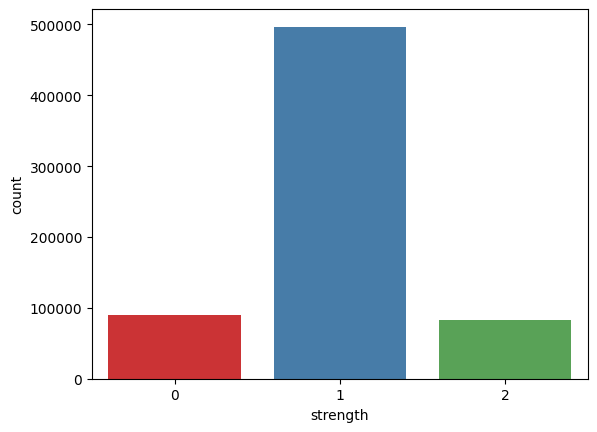

In [9]:
sns.countplot(x='strength', data=df, palette='Set1')
plt.show()

In [10]:
x = df['password']
y = df['strength']

# Creating a Password Strength Tester:

In [11]:
def character(inputs):
    characters = []
    for i in inputs:
        characters.append(i)
    return characters

**Create an NLP function to Check the characters Strength Logic:**

In [12]:
vec = TfidfVectorizer(tokenizer= character)
x = vec.fit_transform(x)

In [13]:
vec.vocabulary_

{'k': 66,
 'z': 81,
 'd': 59,
 'e': 60,
 '5': 39,
 '7': 41,
 'i': 64,
 'n': 69,
 'o': 70,
 '3': 37,
 '4': 38,
 'v': 77,
 's': 74,
 '1': 35,
 'y': 80,
 'r': 73,
 'm': 68,
 'g': 62,
 '2': 36,
 'l': 67,
 'a': 56,
 'b': 57,
 'h': 63,
 'q': 72,
 'f': 61,
 't': 75,
 'u': 76,
 '6': 40,
 'c': 58,
 '8': 42,
 'w': 78,
 '9': 43,
 '0': 34,
 'j': 65,
 'p': 71,
 '@': 49,
 '-': 31,
 'x': 79,
 '.': 32,
 '>': 47,
 '&': 26,
 '?': 48,
 '<': 45,
 '!': 21,
 ';': 44,
 '_': 54,
 '%': 25,
 '±': 99,
 '"': 22,
 '~': 85,
 '+': 30,
 '^': 53,
 '/': 33,
 '$': 24,
 ')': 28,
 ' ': 20,
 '(': 27,
 '#': 23,
 'ú': 138,
 '*': 29,
 '`': 55,
 '{': 82,
 '}': 84,
 '[': 50,
 ']': 52,
 'þ': 142,
 'ó': 132,
 'ô': 133,
 '=': 46,
 '\\': 51,
 '\x1c': 17,
 '³': 101,
 '¿': 112,
 '\x16': 12,
 'ò': 131,
 '·': 105,
 '\x1e': 19,
 '\x19': 15,
 '\x05': 3,
 '\x1b': 16,
 'å': 120,
 '‚': 147,
 'ä': 119,
 'à': 115,
 'õ': 134,
 'ß': 114,
 '´': 102,
 '«': 96,
 'ð': 129,
 'â': 117,
 '°': 98,
 '|': 83,
 '\x7f': 86,
 '²': 100,
 '¾': 111,
 'ÿ': 143,

In [14]:
x.shape

(669639, 153)

**Divide the data into training and test sets:**

In [15]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
print(f"size of the x_train:{x_train.shape}")
print(f"size of the x_test:{x_test.shape}")
print(f"size of the y_train:{y_train.shape}")
print(f"size of the y_test:{y_test.shape}")

size of the x_train:(535711, 153)
size of the x_test:(133928, 153)
size of the y_train:(535711,)
size of the y_test:(133928,)


**Logistic Regression Model To Predict Unseen Passwords Based on the Data:**

In [17]:
lr= LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [18]:
y_pred_test = lr.predict(x_test)
y_pred_train = lr.predict(x_train)

In [19]:
# Calculating the Accuracy Score for both test and training data:
test_acc = accuracy_score(y_test, y_pred_test)
train_acc = accuracy_score(y_train, y_pred_train)
print(f"Test Accuracy:{test_acc}, Training Accuracy:{train_acc}")

Test Accuracy:0.8203512334985963, Training Accuracy:0.818557020483059


**Testing Password Strength On Different ML Models to detect best Benchmark**

# Gradient Boosting:

In [20]:
from  sklearn.ensemble import GradientBoostingClassifier
gb_model =  GradientBoostingClassifier()

In [21]:
gb_model.fit(x_train, y_train)
y_pred_gb = gb_model.predict(x_test)


KeyboardInterrupt: 

In [ ]:
test_acc1 = accuracy_score(y_train, y_pred_gb)
print(f"Test Accuracy:{test_acc1}")

**Data Validation:**

In [ ]:
# For GB Classifier
user_inp = input()
user_inp = np.array([user_inp])
user_inp = vec.transform(user_inp)

y_pred = gb_model.predict(user_inp)
print(f"Model Prediction:{y_pred}")

In [ ]:
# For LR Classifier
user_inp = input()
user_inp = np.array([user_inp])
user_inp = vec.transform(user_inp)

y_pred = lr.predict(user_inp)
print(f"Model Prediction:{y_pred}")